In [2]:
import numpy as np
from scipy.ndimage import map_coordinates
from vedo import Volume

def symmetry_score_z_axis(vol: Volume, angle_deg, threshold=None):
    print(angle_deg)
    arr = vol.tonumpy().astype(float)

    # optional: convert to binary mask
    if threshold is not None:
        arr = arr > threshold

    nx, ny, nz = arr.shape
    cx, cy, cz = (np.array(arr.shape) - 1) / 2

    # voxel coordinate grid
    x, y, z = np.meshgrid(
        np.arange(nx), np.arange(ny), np.arange(nz),
        indexing="ij"
    )

    # center coordinates
    X = x - cx
    Y = y - cy

    theta = np.deg2rad(angle_deg)

    # unit normal of candidate mirror plane in xy
    n = np.array([np.cos(theta), np.sin(theta)])

    # reflect points across vertical plane through center
    dot = X * n[0] + Y * n[1]
    Xr = X - 2 * dot * n[0]
    Yr = Y - 2 * dot * n[1]

    xr = Xr + cx
    yr = Yr + cy
    zr = z

    reflected = map_coordinates(
        arr,
        [xr, yr, zr],
        order=1,
        mode="constant",
        cval=0
    )

    # normalized mean absolute difference
    denom = np.mean(np.abs(arr)) + 1e-9
    score = np.mean(np.abs(arr - reflected)) / denom

    return score


# vol = Volume(r"data\finished_photos\v1\rotated\GH\tif\gras_1_000.tif")  # replace with your volume file path

# angles = np.arange(0, 180, 10)  # mirror planes repeat every 180°
# scores = [symmetry_score_z_axis(vol, a, threshold=None) for a in angles]

# best_angle = angles[np.argmin(scores)]
# best_score = min(scores)

# print("Best symmetry plane angle:", best_angle)
# print("Best score:", best_score)

In [3]:
import numpy as np
from scipy.ndimage import map_coordinates

def symmetry_score_projection(vol, angle_deg, threshold=None, projection="sum"):
    arr = vol.tonumpy().astype(float)

    if threshold is not None:
        arr = arr > threshold

    # project onto bottom two axes: x-y plane
    if projection == "sum":
        img = arr.sum(axis=2)
    elif projection == "max":
        img = arr.max(axis=2)
    elif projection == "mean":
        img = arr.mean(axis=2)
    else:
        raise ValueError("projection must be 'sum', 'max', or 'mean'")

    nx, ny = img.shape
    cx, cy = (np.array(img.shape) - 1) / 2

    x, y = np.meshgrid(
        np.arange(nx),
        np.arange(ny),
        indexing="ij"
    )

    X = x - cx
    Y = y - cy

    theta = np.deg2rad(angle_deg)

    # mirror line normal
    n = np.array([np.cos(theta), np.sin(theta)])

    dot = X * n[0] + Y * n[1]

    Xr = X - 2 * dot * n[0]
    Yr = Y - 2 * dot * n[1]

    xr = Xr + cx
    yr = Yr + cy

    reflected = map_coordinates(
        img,
        [xr, yr],
        order=1,
        mode="constant",
        cval=0
    )

    score = np.mean(np.abs(img - reflected)) / (np.mean(np.abs(img)) + 1e-9)

    return score, img


angles = np.arange(0, 180, 10)

vol = Volume(r"data\finished_photos\v1\rotated\GH\tif\gras_1_003.tif")  # replace with your volume file path

scores = []
for a in angles:
    score, projection_img = symmetry_score_projection(vol, a, threshold=None)
    scores.append(score)

best_angle = angles[np.argmin(scores)]
print("Best symmetry angle:", best_angle)
print("Best score:", min(scores))
from vedo import Volume, show

# show with specific view angles
show(vol,azimuth=best_angle)     # rotate around vertical axis)

Best symmetry angle: 100
Best score: 0.5173157037654481


KeyboardInterrupt: 

PCA estimate: 129.49106396200014
Best symmetry angle: 13.49106396200014
Best symmetry score: 0.322744232860902


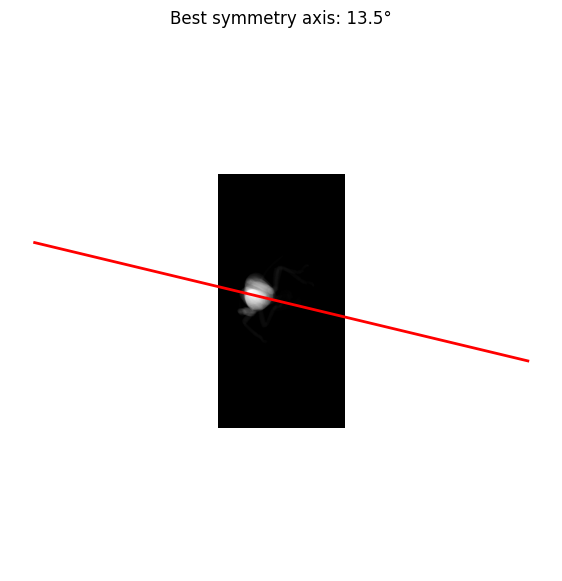

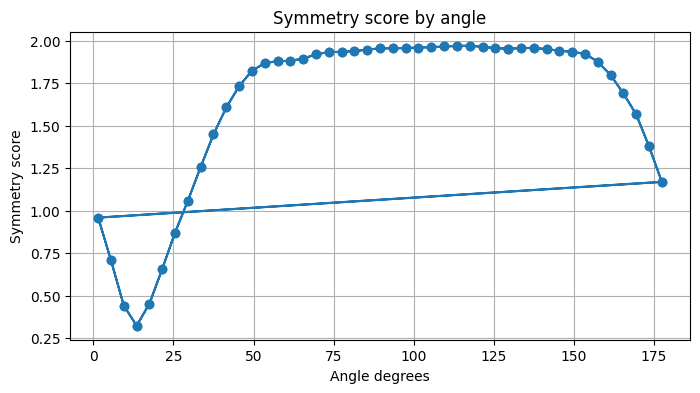

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import map_coordinates


def projection_image(vol, threshold=50, projection="max", axis=2):
    """
    Project a 3D vedo volume into a 2D image.

    axis=2 means project along z, giving x-y image.
    """
    arr = vol.tonumpy().astype(float)

    if threshold is not None:
        arr = (arr > threshold).astype(float)

    if projection == "max":
        img = arr.max(axis=axis)
    elif projection == "sum":
        img = arr.sum(axis=axis)
    elif projection == "mean":
        img = arr.mean(axis=axis)
    else:
        raise ValueError("projection must be 'max', 'sum', or 'mean'")

    return img.astype(float)


def principal_axis_angle(img, threshold=None):
    """
    Estimate main axis of the projected silhouette using PCA.
    Returns angle in degrees, 0-180.
    """
    img = img.astype(float)

    if threshold is None:
        mask = img > img.mean()
    else:
        mask = img > threshold

    y, x = np.nonzero(mask)

    if len(x) < 10:
        raise ValueError("Too few pixels in mask. Try lowering threshold.")

    x = x - x.mean()
    y = y - y.mean()

    coords = np.column_stack([x, y])
    cov = np.cov(coords.T)

    eigvals, eigvecs = np.linalg.eigh(cov)
    main_vec = eigvecs[:, np.argmax(eigvals)]

    angle = np.rad2deg(np.arctan2(main_vec[1], main_vec[0]))

    return angle % 180


def symmetry_score_2d(img, angle_deg):
    """
    Mirror image across a line through the center at angle_deg.
    Lower score = more symmetric.
    """
    img = img.astype(float)

    ny, nx = img.shape
    cy, cx = (np.array(img.shape) - 1) / 2

    y, x = np.meshgrid(
        np.arange(ny),
        np.arange(nx),
        indexing="ij"
    )

    X = x - cx
    Y = y - cy

    theta = np.deg2rad(angle_deg)

    # direction vector of mirror line
    d = np.array([np.cos(theta), np.sin(theta)])

    # normal vector to mirror line
    n = np.array([-d[1], d[0]])

    dot = X * n[0] + Y * n[1]

    Xr = X - 2 * dot * n[0]
    Yr = Y - 2 * dot * n[1]

    xr = Xr + cx
    yr = Yr + cy

    reflected = map_coordinates(
        img,
        [yr, xr],
        order=1,
        mode="constant",
        cval=0
    )

    score = np.mean(np.abs(img - reflected)) / (
        np.mean(np.abs(img)) + 1e-9
    )

    return score


def find_best_symmetry_axis(
    vol,
    threshold=50,
    projection="max",
    axis=2,
    coarse_step=10,
    refine_window=15,
    refine_step=1,
):
    """
    Full workflow:
    1. Project 3D volume to 2D
    2. Estimate main axis using PCA
    3. Search symmetry score around PCA angle
    4. Return best angle and score
    """

    img = projection_image(
        vol,
        threshold=threshold,
        projection=projection,
        axis=axis
    )

    pca_angle = principal_axis_angle(img)

    candidate_angles = np.arange(
        pca_angle - refine_window,
        pca_angle + refine_window + refine_step,
        refine_step
    )

    scores = np.array([
        symmetry_score_2d(img, a)
        for a in candidate_angles
    ])

    best_idx = np.argmin(scores)
    best_angle = candidate_angles[best_idx] % 180
    best_score = scores[best_idx]

    return {
        "image": img,
        "pca_angle": pca_angle,
        "best_angle": best_angle,
        "best_score": best_score,
        "candidate_angles": candidate_angles % 180,
        "scores": scores,
    }


def show_axis(img, angle_deg, title=None):
    """
    Show projected image with symmetry axis overlay.
    """
    img = img.astype(float)

    ny, nx = img.shape
    cy, cx = np.array(img.shape) / 2

    length = max(nx, ny)

    dx = np.cos(np.deg2rad(angle_deg)) * length
    dy = np.sin(np.deg2rad(angle_deg)) * length

    plt.figure(figsize=(7, 7))
    plt.imshow(img, cmap="gray")
    plt.plot(
        [cx - dx, cx + dx],
        [cy - dy, cy + dy],
        "r-",
        linewidth=2
    )
    plt.axis("equal")
    plt.axis("off")

    if title is not None:
        plt.title(title)

    plt.show()


def plot_scores(candidate_angles, scores):
    """
    Plot symmetry score versus tested angle.
    """
    plt.figure(figsize=(8, 4))
    plt.plot(candidate_angles, scores, marker="o")
    plt.xlabel("Angle degrees")
    plt.ylabel("Symmetry score")
    plt.title("Symmetry score by angle")
    plt.grid(True)
    plt.show()


vol = Volume(r"data\finished_photos\v1\rotated\GH\tif\gras_1_003.tif")

# -------------------------
# Usage
# -------------------------

result = find_best_symmetry_axis(
    vol,
    threshold=50,       # adjust for your volume
    projection="mean",   # "max", "sum", or "mean"
    axis=1,             # project along z onto x-y plane
    refine_window=180,   # search +/- 15 degrees around PCA angle
    refine_step=4       # test every 1 degree
)

print("PCA estimate:", result["pca_angle"])
print("Best symmetry angle:", result["best_angle"])
print("Best symmetry score:", result["best_score"])

show_axis(
    result["image"],
    result["best_angle"],
    title=f"Best symmetry axis: {result['best_angle']:.1f}°"
)

plot_scores(
    result["candidate_angles"],
    result["scores"]
)

Best angle: 56.40000000000002
Best symmetry score: 0.3748995610996682


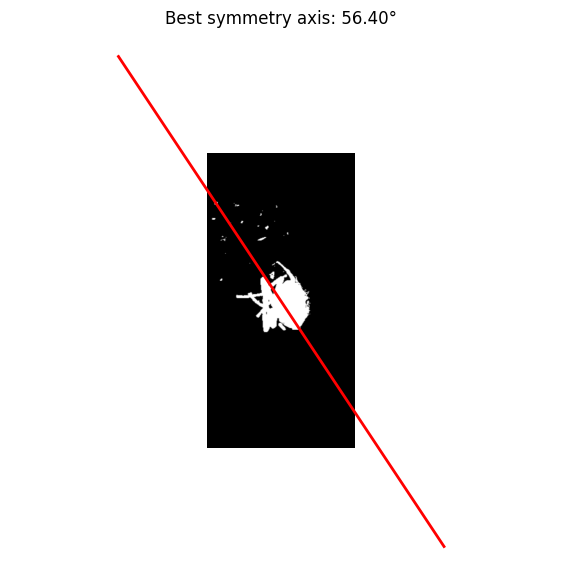

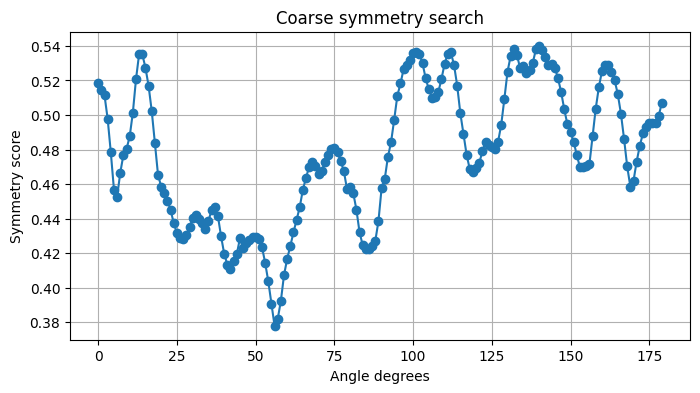

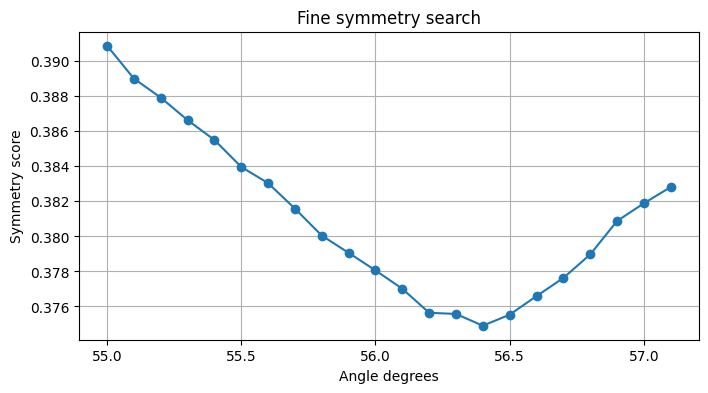

In [11]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import map_coordinates, center_of_mass, shift


def projection_image(vol, threshold=50, projection="max", axis=2):
    arr = vol.tonumpy().astype(float)

    if threshold is not None:
        arr = (arr > threshold).astype(float)

    if projection == "max":
        img = arr.max(axis=axis)
    elif projection == "sum":
        img = arr.sum(axis=axis)
    elif projection == "mean":
        img = arr.mean(axis=axis)
    else:
        raise ValueError("projection must be 'max', 'sum', or 'mean'")

    return img.astype(float)


def center_image(img):
    mask = img > 0

    if mask.sum() == 0:
        raise ValueError("Mask is empty. Try lowering the threshold.")

    cy, cx = center_of_mass(mask)

    ny, nx = img.shape
    target_cy = (ny - 1) / 2
    target_cx = (nx - 1) / 2

    centered = shift(
        img,
        shift=(target_cy - cy, target_cx - cx),
        order=1,
        mode="constant",
        cval=0
    )

    return centered


def symmetry_score_2d_masked(img, angle_deg):
    img = img.astype(float)
    mask = img > 0

    ny, nx = img.shape
    cy, cx = (np.array(img.shape) - 1) / 2

    y, x = np.meshgrid(
        np.arange(ny),
        np.arange(nx),
        indexing="ij"
    )

    X = x - cx
    Y = y - cy

    theta = np.deg2rad(angle_deg)

    # direction of candidate symmetry axis
    d = np.array([np.cos(theta), np.sin(theta)])

    # normal to that axis
    n = np.array([-d[1], d[0]])

    dot = X * n[0] + Y * n[1]

    Xr = X - 2 * dot * n[0]
    Yr = Y - 2 * dot * n[1]

    xr = Xr + cx
    yr = Yr + cy

    reflected_img = map_coordinates(
        img,
        [yr, xr],
        order=1,
        mode="constant",
        cval=0
    )

    reflected_mask = map_coordinates(
        mask.astype(float),
        [yr, xr],
        order=0,
        mode="constant",
        cval=0
    ) > 0.5

    compare_mask = mask | reflected_mask

    if compare_mask.sum() == 0:
        return np.inf

    score = np.mean(
        np.abs(img[compare_mask] - reflected_img[compare_mask])
    ) / (np.mean(np.abs(img[compare_mask])) + 1e-9)

    return score


def find_best_symmetry_axis(
    vol,
    threshold=50,
    projection="max",
    axis=2,
    coarse_step=1,
    fine_window=1,
    fine_step=0.1,
    binary=True,
):
    img = projection_image(
        vol,
        threshold=threshold,
        projection=projection,
        axis=axis
    )

    if binary:
        img = (img > 0).astype(float)

    img = center_image(img)

    coarse_angles = np.arange(0, 180, coarse_step)

    coarse_scores = np.array([
        symmetry_score_2d_masked(img, a)
        for a in coarse_angles
    ])

    coarse_best_angle = coarse_angles[np.argmin(coarse_scores)]

    fine_angles = np.arange(
        coarse_best_angle - fine_window,
        coarse_best_angle + fine_window + fine_step,
        fine_step
    )

    fine_scores = np.array([
        symmetry_score_2d_masked(img, a)
        for a in fine_angles
    ])

    best_angle = fine_angles[np.argmin(fine_scores)] % 180
    best_score = fine_scores.min()

    return {
        "image": img,
        "best_angle": best_angle,
        "best_score": best_score,
        "coarse_angles": coarse_angles,
        "coarse_scores": coarse_scores,
        "fine_angles": fine_angles % 180,
        "fine_scores": fine_scores,
    }


def show_axis(img, angle_deg, title=None):
    ny, nx = img.shape
    cy, cx = np.array(img.shape) / 2

    length = max(nx, ny)

    dx = np.cos(np.deg2rad(angle_deg)) * length
    dy = np.sin(np.deg2rad(angle_deg)) * length

    plt.figure(figsize=(7, 7))
    plt.imshow(img, cmap="gray")
    plt.plot(
        [cx - dx, cx + dx],
        [cy - dy, cy + dy],
        "r-",
        linewidth=2
    )
    plt.axis("equal")
    plt.axis("off")

    if title is not None:
        plt.title(title)

    plt.show()


def plot_scores(angles, scores, title="Symmetry score by angle"):
    order = np.argsort(angles)

    plt.figure(figsize=(8, 4))
    plt.plot(angles[order], scores[order], marker="o")
    plt.xlabel("Angle degrees")
    plt.ylabel("Symmetry score")
    plt.title(title)
    plt.grid(True)
    plt.show()


# -------------------------
# Usage
# -------------------------

vol = Volume(r"data\finished_photos\v1\rotated\BF\tif\spy_1_000.tif")

result = find_best_symmetry_axis(
    vol,
    threshold=50,        # adjust this
    projection="max",    # "max", "sum", or "mean"
    axis=1,              # project along z onto x-y plane
    coarse_step=1,       # search every 1 degree
    fine_window=1,       # refine +/- 1 degree
    fine_step=0.1,       # refine every 0.1 degree
    binary=True          # use silhouette shape
)

print("Best angle:", result["best_angle"])
print("Best symmetry score:", result["best_score"])

show_axis(
    result["image"],
    result["best_angle"],
    title=f"Best symmetry axis: {result['best_angle']:.2f}°"
)

plot_scores(
    result["coarse_angles"],
    result["coarse_scores"],
    title="Coarse symmetry search"
)

plot_scores(
    result["fine_angles"],
    result["fine_scores"],
    title="Fine symmetry search"
)